# GMMVAE Clusters vs Ground-Truth Methylation Classes
Steps 3–5: metrics, confusion matrix, and visualizations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score,
    confusion_matrix
)

sns.set_theme(style='whitegrid', font_scale=1.05)

DATA_PATH  = 'output_gmmvae/cluster_vs_label.csv'
UMAP_PATH  = 'output_gmmvae/embedding_2d_umap.csv'

## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
umap_df = pd.read_csv(UMAP_PATH)[['sample', 'dim1', 'dim2']]
df = df.merge(umap_df, on='sample', how='left')

print(f'Samples        : {len(df)}')
print(f'Model clusters : {df["cluster"].nunique()}')
print(f'True classes   : {df["methylation_class"].nunique()}')
df.head()

Samples        : 2801
Model clusters : 15
True classes   : 91


,sample,cluster,methylation_class,dim1,dim2
0,SAMPLE 1,7,"GBM, G34",12.010082,-0.151519
1,SAMPLE 2,14,"DMG, K27",8.221077,1.322747
2,SAMPLE 3,14,"DMG, K27",8.536789,1.187312
3,SAMPLE 4,14,"DMG, K27",8.064356,1.218112
4,SAMPLE 5,14,"DMG, K27",8.566692,1.283884


## 2. Clustering Evaluation Metrics

                      Metric  Score
   Adjusted Rand Index (ARI) 0.2179
Normalized Mutual Info (NMI) 0.6679
                 Homogeneity 0.5157
                Completeness 0.9477
                   V-measure 0.6679


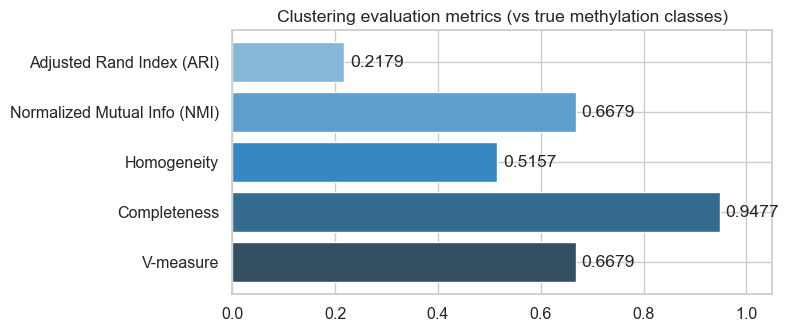

In [3]:
true  = df['methylation_class']
pred  = df['cluster']

metrics = {
    'Adjusted Rand Index (ARI)'         : adjusted_rand_score(true, pred),
    'Normalized Mutual Info (NMI)'       : normalized_mutual_info_score(true, pred),
    'Homogeneity'                        : homogeneity_score(true, pred),
    'Completeness'                       : completeness_score(true, pred),
    'V-measure'                          : v_measure_score(true, pred),
}

metrics_df = pd.DataFrame(metrics.items(), columns=['Metric', 'Score'])
metrics_df['Score'] = metrics_df['Score'].round(4)
print(metrics_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(metrics_df['Metric'], metrics_df['Score'],
               color=sns.color_palette('Blues_d', len(metrics_df)))
ax.bar_label(bars, fmt='%.4f', padding=4)
ax.set_xlim(0, 1.05)
ax.set_title('Clustering evaluation metrics (vs true methylation classes)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('output_gmmvae/metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Per-Class Purity
For each true class, what fraction of its samples ended up in the single most common cluster?

In [4]:
def class_purity(group):
    counts = group['cluster'].value_counts()
    dominant_cluster = counts.index[0]
    purity = counts.iloc[0] / len(group)
    return pd.Series({'dominant_cluster': dominant_cluster,
                      'purity': purity,
                      'n': len(group)})

purity_df = df.groupby('methylation_class').apply(class_purity).reset_index()
purity_df = purity_df.sort_values('purity', ascending=False)

print(f'Mean purity across classes: {purity_df["purity"].mean():.4f}')
print(f'Classes with purity > 0.8 : {(purity_df["purity"] > 0.8).sum()}')
print(f'Classes with purity < 0.5 : {(purity_df["purity"] < 0.5).sum()}')
print()
print('Top 10 purest classes:')
print(purity_df.head(10).to_string(index=False))
print()
print('Bottom 10 (most mixed) classes:')
print(purity_df.tail(10).to_string(index=False))

Mean purity across classes: 0.9443
Classes with purity > 0.8 : 83
Classes with purity < 0.5 : 0

Top 10 purest classes:
methylation_class  dominant_cluster  purity     n
            A IDH              12.0     1.0  78.0
      HGNET, BCOR              11.0     1.0  23.0
          PGG, nC               4.0     1.0  19.0
          MB, WNT              13.0     1.0  39.0
           MB, G4              13.0     1.0 138.0
           MB, G3              13.0     1.0  77.0
           LYMPHO               2.0     1.0  13.0
             LIPN               1.0     1.0  10.0
        LGG, SEGA               4.0     1.0  21.0
        LGG, RGNT               4.0     1.0   9.0

Bottom 10 (most mixed) classes:
methylation_class  dominant_cluster   purity    n
         EPN, YAP               4.0 0.818182 11.0
       HGNET, MN1              11.0 0.809524 21.0
      CONTR, CEBM               1.0 0.750000  8.0
           CHORDM               6.0 0.666667  9.0
           ANA PA               4.0 0.619048 21

/var/folders/vt/gt2z9qkn6xz0mqpgw5fxzyw00000gn/T/ipykernel_76691/1540300868.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  purity_df = df.groupby('methylation_class').apply(class_purity).reset_index()


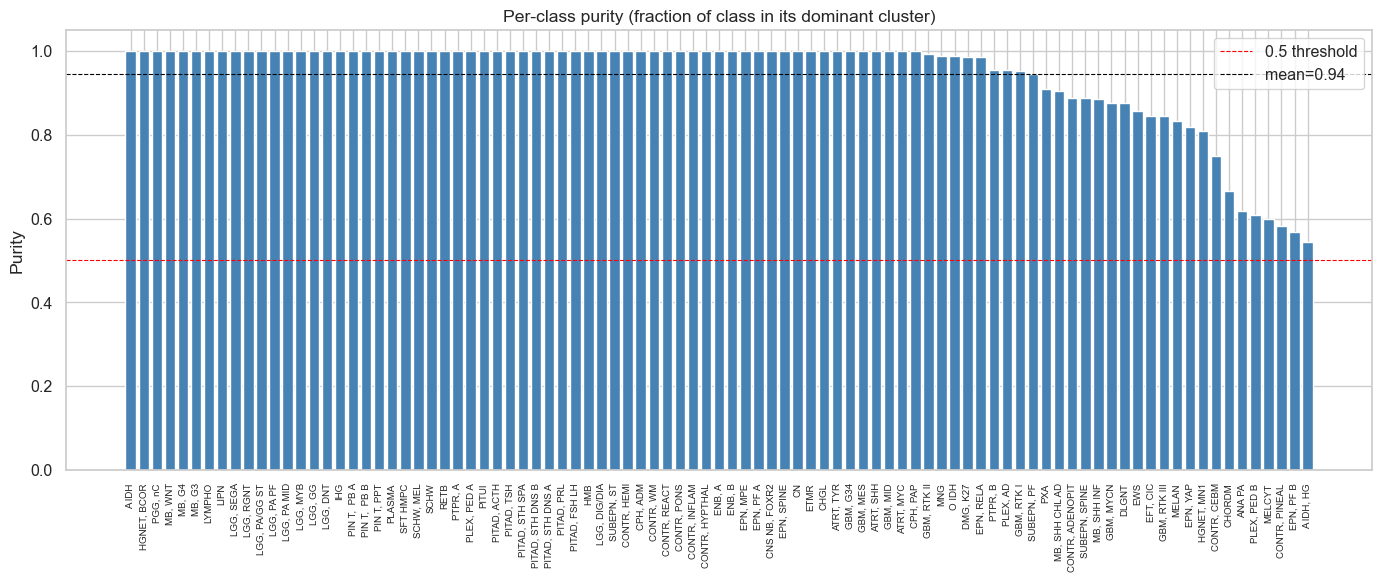

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['steelblue' if p >= 0.5 else 'coral' for p in purity_df['purity']]
ax.bar(range(len(purity_df)), purity_df['purity'], color=colors)
ax.set_xticks(range(len(purity_df)))
ax.set_xticklabels(purity_df['methylation_class'], rotation=90, fontsize=7)
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='0.5 threshold')
ax.axhline(purity_df['purity'].mean(), color='black', linestyle='--',
           linewidth=0.8, label=f'mean={purity_df["purity"].mean():.2f}')
ax.set_title('Per-class purity (fraction of class in its dominant cluster)')
ax.set_ylabel('Purity')
ax.legend()
plt.tight_layout()
plt.savefig('output_gmmvae/class_purity.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Confusion Matrix — True Classes × Model Clusters

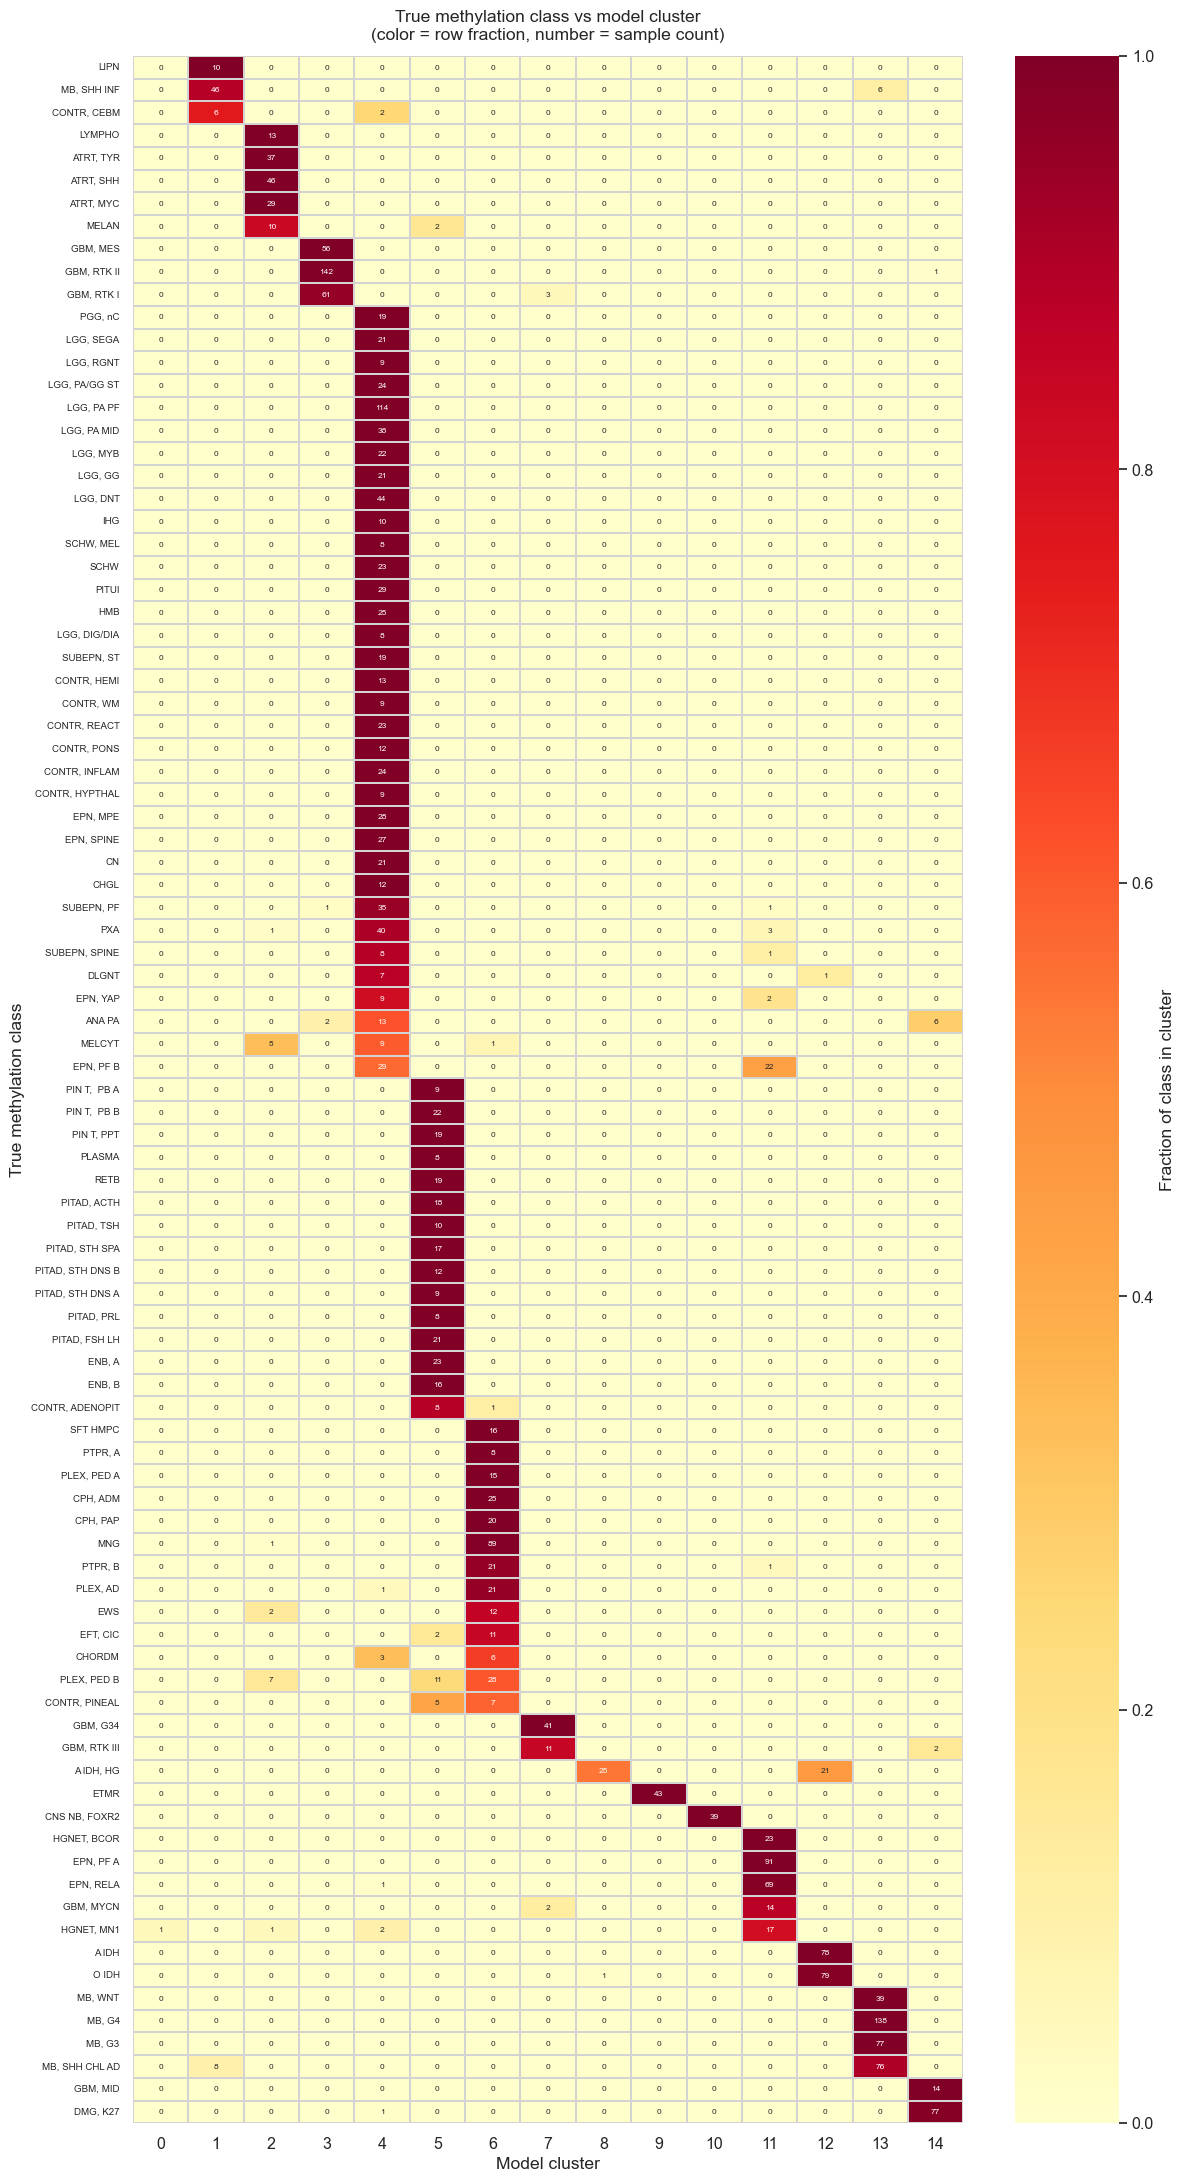

In [6]:
# Sort classes by dominant cluster to group visually
class_order = purity_df.sort_values(['dominant_cluster', 'purity'],
                                     ascending=[True, False])['methylation_class'].tolist()
cluster_order = sorted(df['cluster'].unique())

ct = pd.crosstab(df['methylation_class'], df['cluster'])
ct = ct.reindex(class_order).fillna(0)

# Row-normalise (fraction of each class going to each cluster)
ct_norm = ct.div(ct.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 22))
sns.heatmap(
    ct_norm,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='lightgrey',
    annot=ct.values.astype(int),
    fmt='d',
    annot_kws={'size': 6},
    cbar_kws={'label': 'Fraction of class in cluster'},
    vmin=0, vmax=1
)
ax.set_title('True methylation class vs model cluster\n(color = row fraction, number = sample count)', pad=12)
ax.set_xlabel('Model cluster')
ax.set_ylabel('True methylation class')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
plt.tight_layout()
plt.savefig('output_gmmvae/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Per-Cluster Composition
What tumor classes make up each model cluster?

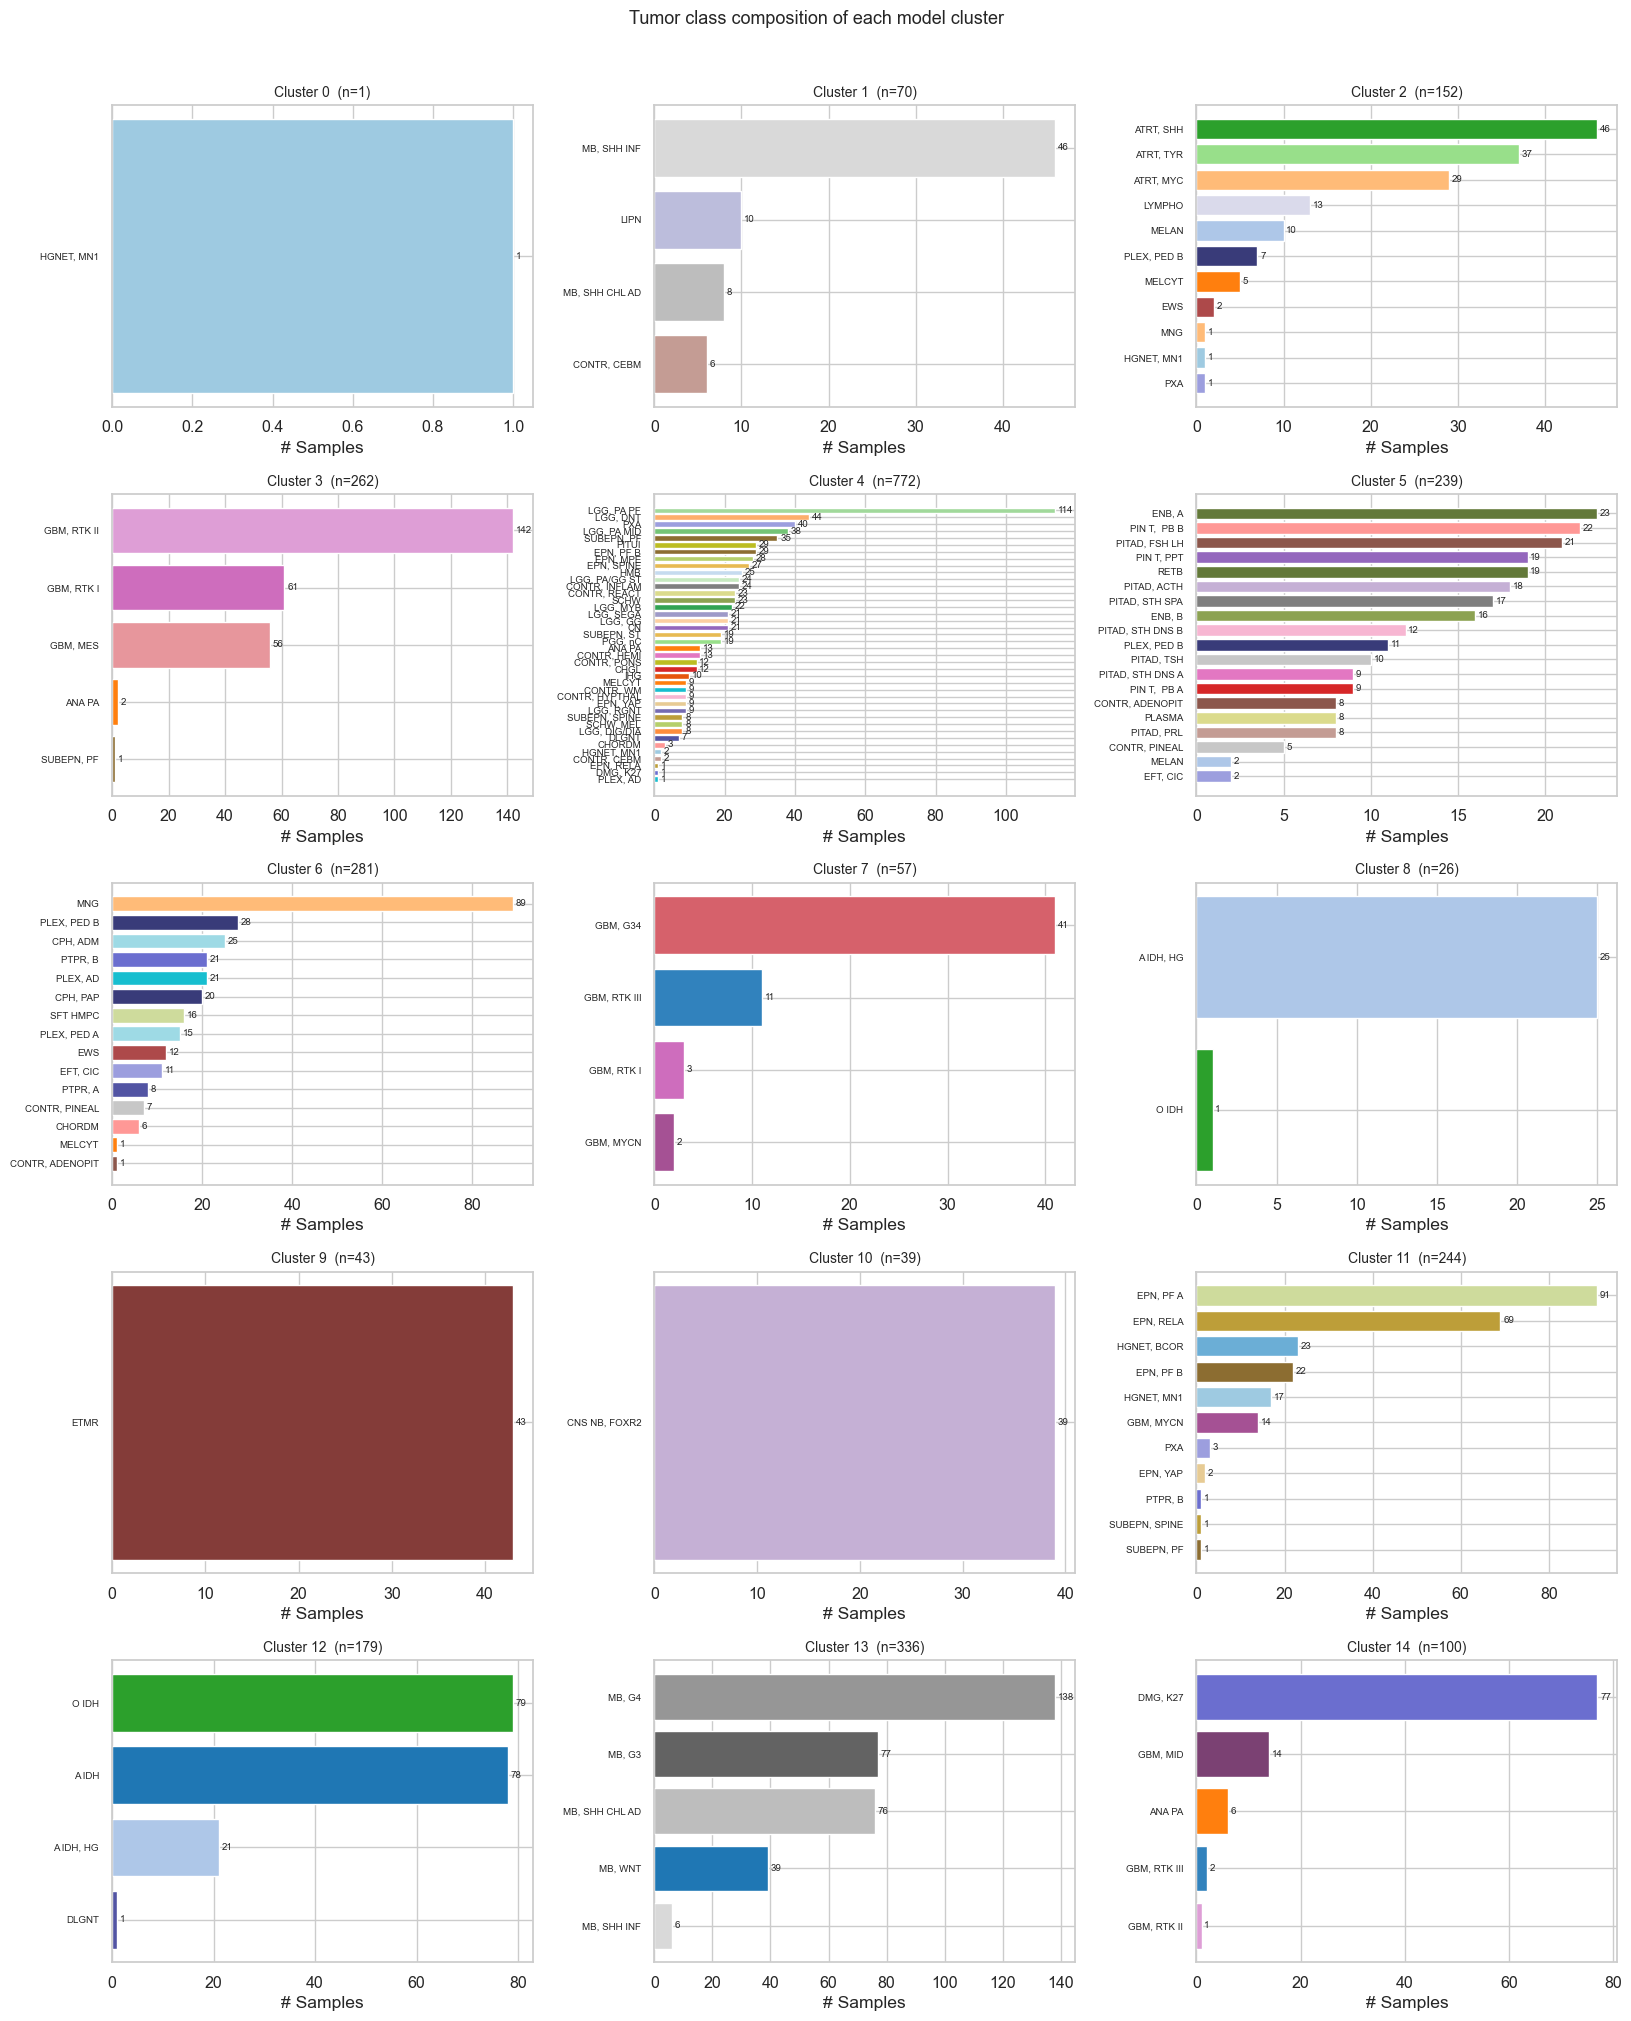

In [7]:
n_clusters = df['cluster'].nunique()
ncols = 3
nrows = int(np.ceil(n_clusters / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.5, nrows * 4))
axes = np.array(axes).ravel()

palette = sns.color_palette('tab20', 20) + sns.color_palette('tab20b', 20) + sns.color_palette('tab20c', 20)
all_classes = sorted(df['methylation_class'].unique())
class_color = {c: palette[i % len(palette)] for i, c in enumerate(all_classes)}

for i, c in enumerate(sorted(df['cluster'].unique())):
    ax = axes[i]
    sub = df[df['cluster'] == c]['methylation_class'].value_counts()
    colors = [class_color[cls] for cls in sub.index]
    bars = ax.barh(sub.index, sub.values, color=colors)
    ax.bar_label(bars, padding=2, fontsize=7)
    ax.set_title(f'Cluster {c}  (n={len(df[df["cluster"]==c])})', fontsize=10)
    ax.set_xlabel('# Samples')
    ax.tick_params(axis='y', labelsize=7)
    ax.invert_yaxis()

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tumor class composition of each model cluster', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('output_gmmvae/cluster_composition.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. UMAP — Model Clusters vs True Labels Side-by-Side

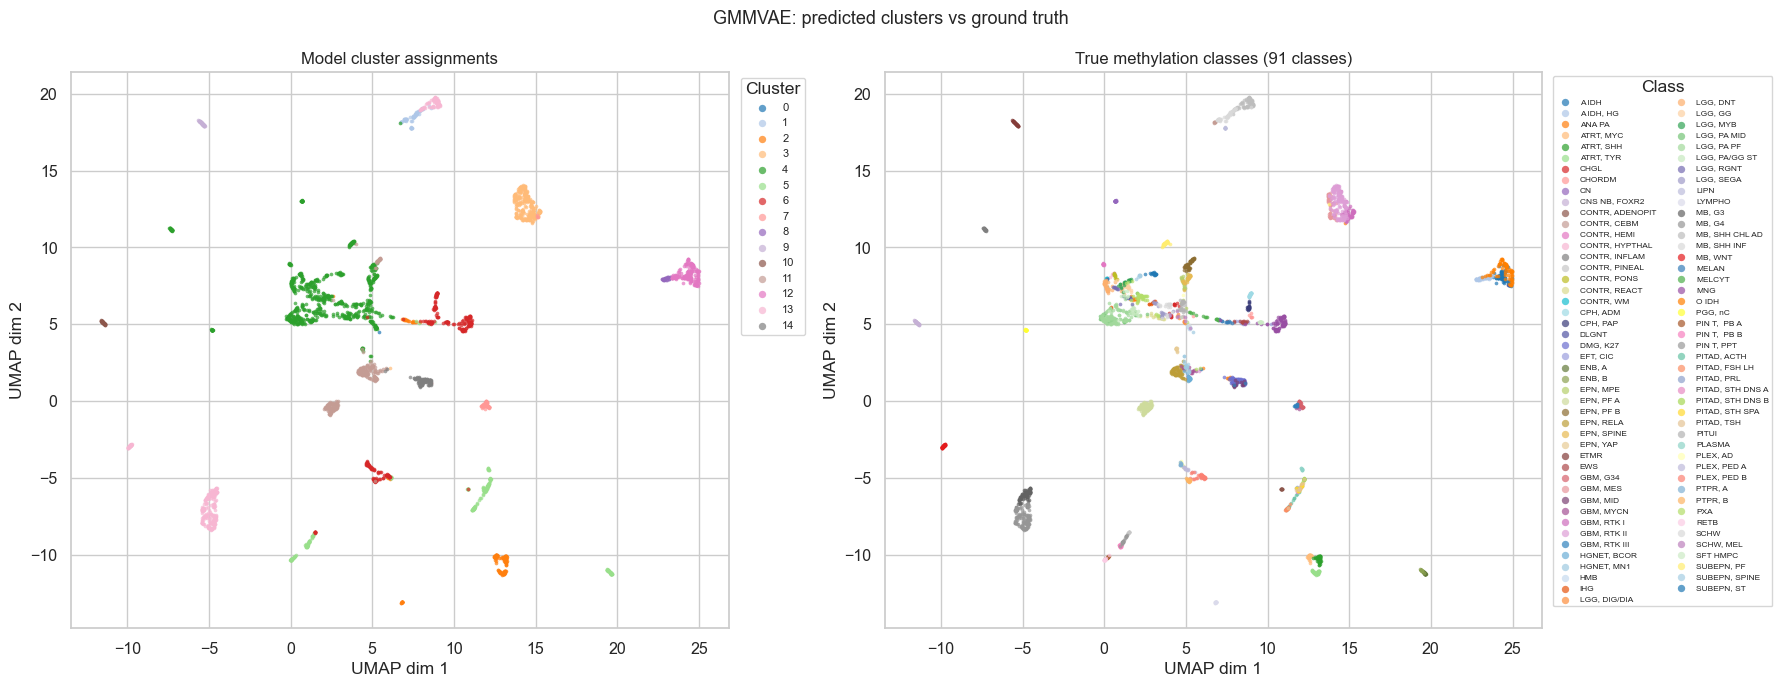

In [8]:
# Build color maps
cluster_ids = sorted(df['cluster'].unique())
cluster_palette = sns.color_palette('tab20', len(cluster_ids))
cluster_color = {c: cluster_palette[i] for i, c in enumerate(cluster_ids)}

class_ids = sorted(df['methylation_class'].unique())
class_palette = (sns.color_palette('tab20', 20) +
                 sns.color_palette('tab20b', 20) +
                 sns.color_palette('tab20c', 20) +
                 sns.color_palette('Set1', 9) +
                 sns.color_palette('Set2', 8) +
                 sns.color_palette('Set3', 12) +
                 sns.color_palette('Paired', 12))
class_color_map = {c: class_palette[i % len(class_palette)] for i, c in enumerate(class_ids)}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: model clusters
for c in cluster_ids:
    mask = df['cluster'] == c
    axes[0].scatter(df.loc[mask, 'dim1'], df.loc[mask, 'dim2'],
                    c=[cluster_color[c]], s=7, alpha=0.7, linewidths=0, label=str(c))
axes[0].set_title('Model cluster assignments', fontsize=12)
axes[0].set_xlabel('UMAP dim 1')
axes[0].set_ylabel('UMAP dim 2')
axes[0].legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left',
               markerscale=2, fontsize=8)

# Right: true methylation classes
for cls in class_ids:
    mask = df['methylation_class'] == cls
    axes[1].scatter(df.loc[mask, 'dim1'], df.loc[mask, 'dim2'],
                    c=[class_color_map[cls]], s=7, alpha=0.7, linewidths=0, label=cls)
axes[1].set_title('True methylation classes (91 classes)', fontsize=12)
axes[1].set_xlabel('UMAP dim 1')
axes[1].set_ylabel('UMAP dim 2')
axes[1].legend(title='Class', bbox_to_anchor=(1.01, 1), loc='upper left',
               markerscale=2, fontsize=6, ncol=2)

plt.suptitle('GMMVAE: predicted clusters vs ground truth', fontsize=13)
plt.tight_layout()
plt.savefig('output_gmmvae/umap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. UMAP — Highlight Dominant Classes per Cluster

In [9]:
# For each cluster show which true class dominates it (top-1 by count)
dominant = df.groupby('cluster')['methylation_class'].agg(
    lambda x: x.value_counts().index[0]
).to_dict()

print('Dominant true class per model cluster:')
for c, cls in sorted(dominant.items()):
    n_total = (df['cluster'] == c).sum()
    n_dom   = ((df['cluster'] == c) & (df['methylation_class'] == cls)).sum()
    print(f'  Cluster {c:2d}: {cls:<25s}  {n_dom}/{n_total} ({n_dom/n_total*100:.1f}%)')

Dominant true class per model cluster:
  Cluster  0: HGNET, MN1                 1/1 (100.0%)
  Cluster  1: MB, SHH INF                46/70 (65.7%)
  Cluster  2: ATRT, SHH                  46/152 (30.3%)
  Cluster  3: GBM, RTK II                142/262 (54.2%)
  Cluster  4: LGG, PA PF                 114/772 (14.8%)
  Cluster  5: ENB, A                     23/239 (9.6%)
  Cluster  6: MNG                        89/281 (31.7%)
  Cluster  7: GBM, G34                   41/57 (71.9%)
  Cluster  8: A IDH, HG                  25/26 (96.2%)
  Cluster  9: ETMR                       43/43 (100.0%)
  Cluster 10: CNS NB, FOXR2              39/39 (100.0%)
  Cluster 11: EPN, PF A                  91/244 (37.3%)
  Cluster 12: O IDH                      79/179 (44.1%)
  Cluster 13: MB, G4                     138/336 (41.1%)
  Cluster 14: DMG, K27                   77/100 (77.0%)


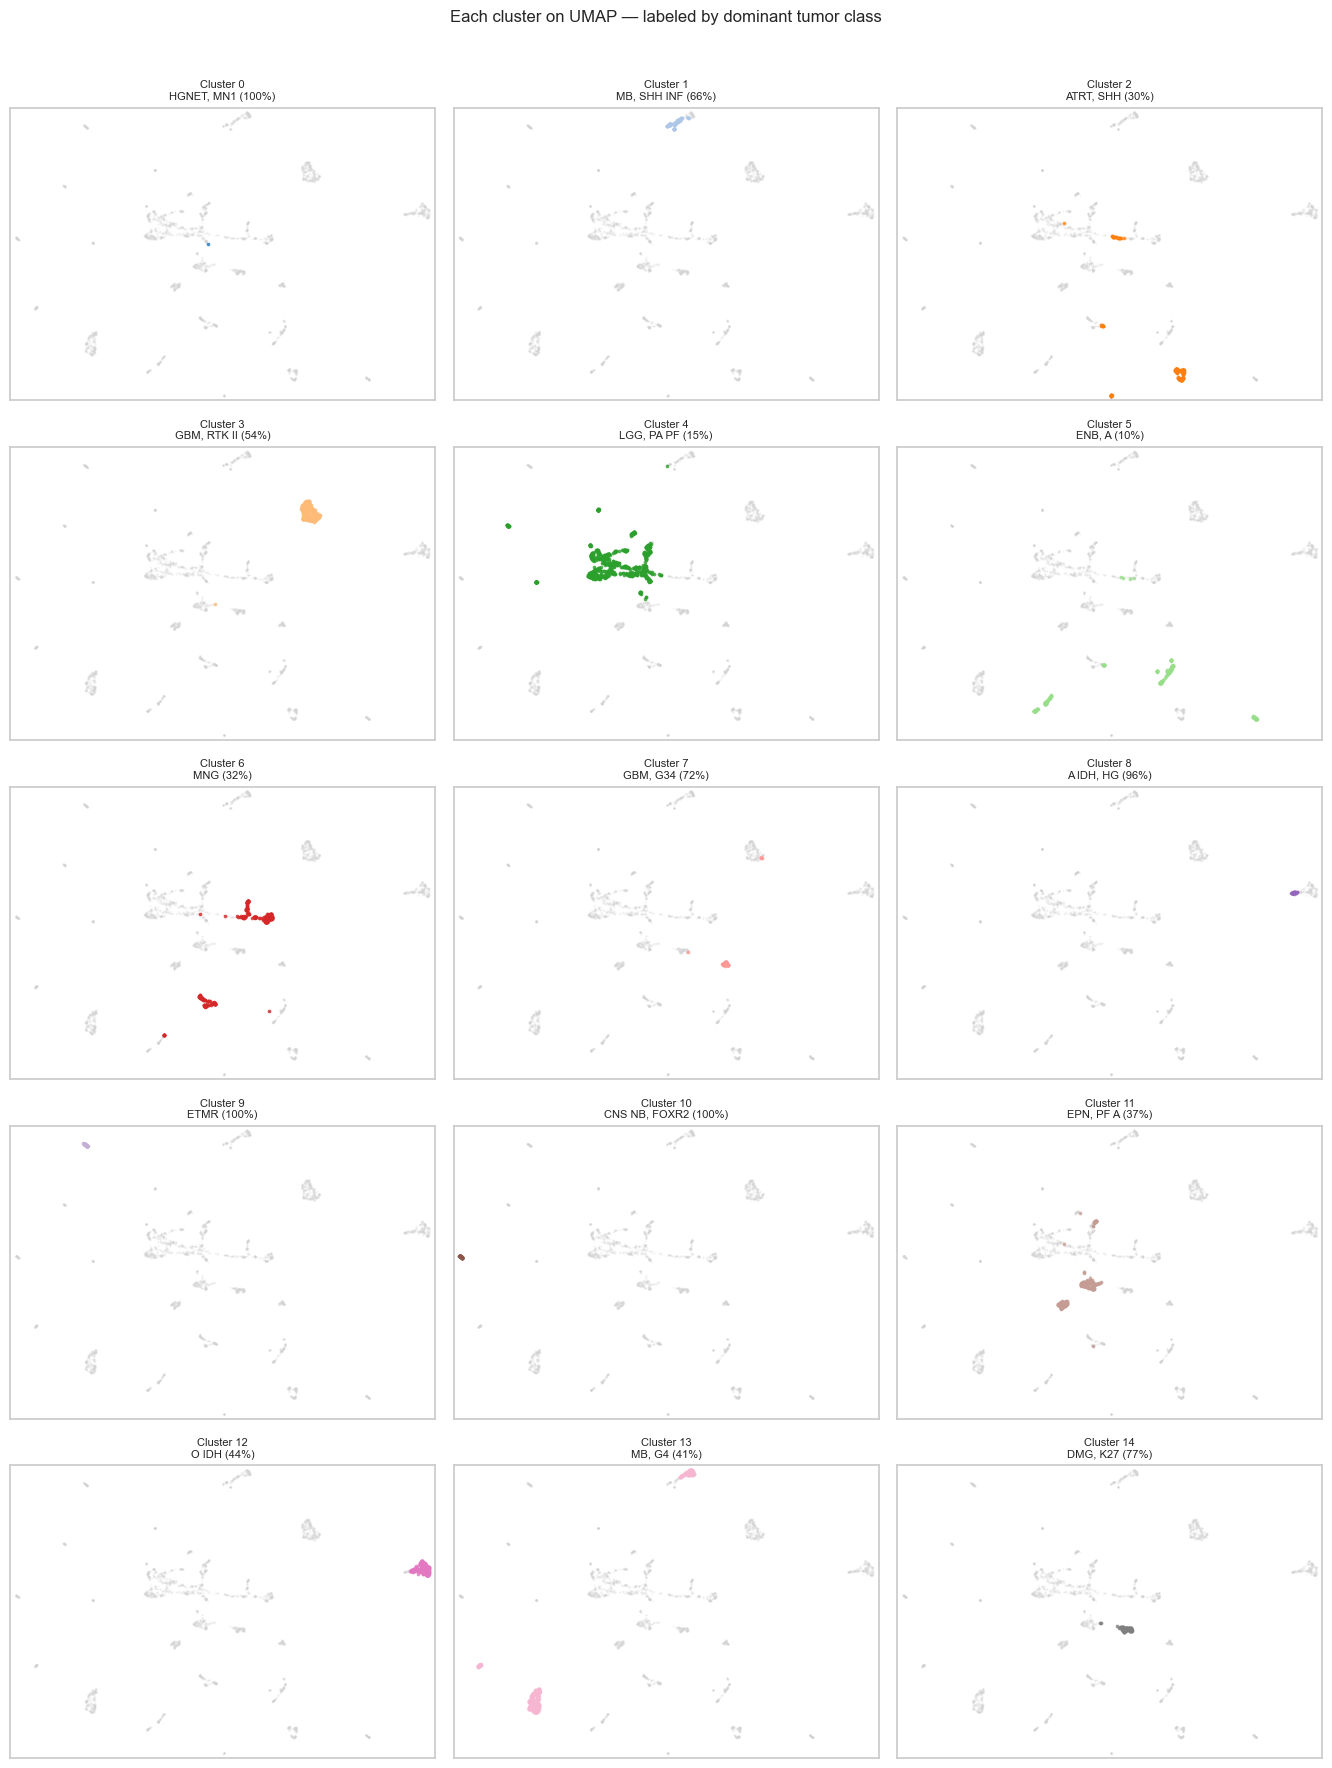

In [10]:
ncols = 3
nrows = int(np.ceil(len(cluster_ids) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3.5))
axes = np.array(axes).ravel()

x_all, y_all = df['dim1'].values, df['dim2'].values
xlim = (x_all.min() - 0.5, x_all.max() + 0.5)
ylim = (y_all.min() - 0.5, y_all.max() + 0.5)

for i, c in enumerate(sorted(cluster_ids)):
    ax = axes[i]
    mask = df['cluster'] == c
    dom_cls = dominant[c]
    n_total = mask.sum()
    n_dom = ((df['cluster'] == c) & (df['methylation_class'] == dom_cls)).sum()

    ax.scatter(x_all, y_all, s=2, c='lightgrey', alpha=0.25, linewidths=0)
    ax.scatter(df.loc[mask, 'dim1'], df.loc[mask, 'dim2'],
               c=[cluster_color[c]], s=7, alpha=0.8, linewidths=0)
    ax.set_title(f'Cluster {c}\n{dom_cls} ({n_dom/n_total*100:.0f}%)', fontsize=8)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xticks([])
    ax.set_yticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Each cluster on UMAP — labeled by dominant tumor class', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('output_gmmvae/umap_dominant_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary Table

In [11]:
summary_rows = []
for c in sorted(cluster_ids):
    sub = df[df['cluster'] == c]
    top3 = sub['methylation_class'].value_counts().head(3)
    dom_cls = top3.index[0]
    dom_n   = top3.iloc[0]
    purity  = dom_n / len(sub)
    top3_str = ' | '.join([f'{cls} ({n})' for cls, n in top3.items()])
    summary_rows.append({
        'cluster'          : c,
        'n_samples'        : len(sub),
        'n_classes'        : sub['methylation_class'].nunique(),
        'dominant_class'   : dom_cls,
        'dominant_purity'  : round(purity, 3),
        'top3_classes'     : top3_str,
    })

summary = pd.DataFrame(summary_rows)
summary.to_csv('output_gmmvae/cluster_summary.csv', index=False)
print(summary.to_string(index=False))

 cluster  n_samples  n_classes dominant_class  dominant_purity                                         top3_classes
       0          1          1     HGNET, MN1            1.000                                       HGNET, MN1 (1)
       1         70          4    MB, SHH INF            0.657    MB, SHH INF (46) | LIPN (10) | MB, SHH CHL AD (8)
       2        152         11      ATRT, SHH            0.303     ATRT, SHH (46) | ATRT, TYR (37) | ATRT, MYC (29)
       3        262          5    GBM, RTK II            0.542  GBM, RTK II (142) | GBM, RTK I (61) | GBM, MES (56)
       4        772         40     LGG, PA PF            0.148          LGG, PA PF (114) | LGG, DNT (44) | PXA (40)
       5        239         19         ENB, A            0.096 ENB, A (23) | PIN T,  PB B (22) | PITAD, FSH LH (21)
       6        281         15            MNG            0.317          MNG (89) | PLEX, PED B (28) | CPH, ADM (25)
       7         57          4       GBM, G34            0.719   GBM, G3